In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random

# 머신러닝 & 딥러닝 모델, 평가 지표
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.neural_network import MLPRegressor  # 딥러닝 베이스라인
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

#딥러닝
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# 한글 폰트 설정 
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

In [2]:
episodes_path = "../db/data/episodes.csv"
works_path = "../db/data/works.csv"

df_episodes = pd.read_csv(episodes_path)
df_works = pd.read_csv(works_path)

데이터 확인 작업

In [3]:
print(df_episodes.shape, df_works.shape)

(3399235, 15) (79674, 48)


In [4]:
df_episodes.head()

,work_id,episode_id,episode_number,episode_title,published_at,access_type,view_count,like_count,comment_count,page_count,adult,paid_conversion_before_entry,up,collected_at,source_url
0,1,94299,1,인트로,2012-04-08T06:12:35,FREE,9001,34,11,10,False,False,False,2026-07-29T17:21:56.093365,https://www.munpia.com/novel/detail/1
1,1,94412,2,Maid in Seoul(1),2012-04-09T06:23:04,FREE,7052,45,13,9,False,False,False,2026-07-29T17:21:56.093365,https://www.munpia.com/novel/detail/1
2,1,94519,3,Maid in Seoul(2),2012-04-10T06:07:30,FREE,6192,35,6,10,False,False,False,2026-07-29T17:21:56.093365,https://www.munpia.com/novel/detail/1
3,1,94614,4,Maid in Seoul(3),2012-04-11T06:13:54,FREE,5808,38,5,12,False,False,False,2026-07-29T17:21:56.093365,https://www.munpia.com/novel/detail/1
4,1,94637,5,죽어버린 신들의 세계(1),2012-04-11T12:02:43,FREE,5648,32,4,8,False,False,False,2026-07-29T17:21:56.093365,https://www.munpia.com/novel/detail/1


In [5]:
df_works.head()

,work_id,source_url,title,author_name,illustrator_name,introduction,cover_url,origin_cover_url,group_name,genres_json,...,female_count,age_10s_percent,age_20s_percent,age_30s_percent,age_40s_percent,age_50s_percent,notice_count,notices_json,events_json,collected_at
0,1,https://www.munpia.com/novel/detail/1,악마가 악마를 만나다,웃는너구리,NaN,NaN,https://cdn1.munpia.com/v2/attachment/covers-v...,https://cdn1.munpia.com/v2/attachment/covers-v...,일반연재,"[""퓨전""]",...,NaN,NaN,NaN,NaN,NaN,NaN,0,[],[],2026-07-29T17:21:56.093365
1,4,https://www.munpia.com/novel/detail/4,강철의 무황,만필공,NaN,NaN,https://cdn1.munpia.com/v2/attachment/covers-v...,https://cdn1.munpia.com/v2/attachment/covers-v...,자유연재,"[""판타지""]",...,NaN,NaN,NaN,NaN,NaN,NaN,0,[],[],2026-07-29T17:21:56.097365
2,5,https://www.munpia.com/novel/detail/5,절대권력,곰돌이푸마,NaN,말이란 입으로 하는게 아니라 주먹으로 하는 것이다.,https://cdn1.munpia.com/v2/attachment/covers/h...,https://cdn1.munpia.com/v2/attachment/covers/h...,자유연재,"[""무협""]",...,NaN,NaN,NaN,NaN,NaN,NaN,1,"[{""id"": 110155, ""title"": ""반갑습니다."", ""createdAt""...",[],2026-07-29T17:21:56.097365
3,10,https://www.munpia.com/novel/detail/10,타머하켄,KarlLee,NaN,NaN,https://cdn1.munpia.com/v2/attachment/covers-v...,https://cdn1.munpia.com/v2/attachment/covers-v...,작가연재,"[""현대판타지""]",...,NaN,NaN,NaN,NaN,NaN,NaN,0,[],[],2026-07-29T17:21:56.097365
4,11,https://www.munpia.com/novel/detail/11,고수,백준,NaN,NaN,https://cdn1.munpia.com/v2/attachment/covers-v...,https://cdn1.munpia.com/v2/attachment/covers-v...,작가연재,"[""무협""]",...,NaN,NaN,NaN,NaN,NaN,NaN,1,"[{""id"": 25230, ""title"": ""안녕하세요. 백준입니다."", ""crea...",[],2026-07-29T17:21:56.097365


##### 사용할 데이터와 컬럼

df_episodes 
- work_id : 작품 고유 번호
- episode_number : 회차 번호
- access_type : 무료/유료 여부
- view_count : 조회수 (Target)
- like_count : 좋아요 수
- comment_count : 댓글 수
- page_count : 페이지 수 / 분량
- published_at : 연재일시

df_works
- work_id : 작품 고유 번호
- title : 제목
- author_name : 작가명
- group_name : 연재 종류
- genre_best_name : 장르
- preference_count : 선호작 수
- exclusive : 독점 연재 여부
- contest: 공모전 여부
- adult : 성인물 여부

In [6]:
episodes_cols = [
    'work_id', 'episode_number', 'access_type', 
    'view_count', 'like_count', 'comment_count', 'page_count', 'published_at'
]
df_ep = df_episodes[episodes_cols].copy()
df_ep

,work_id,episode_number,access_type,view_count,like_count,comment_count,page_count,published_at
0,1,1,FREE,9001,34,11,10,2012-04-08T06:12:35
1,1,2,FREE,7052,45,13,9,2012-04-09T06:23:04
2,1,3,FREE,6192,35,6,10,2012-04-10T06:07:30
3,1,4,FREE,5808,38,5,12,2012-04-11T06:13:54
4,1,5,FREE,5648,32,4,8,2012-04-11T12:02:43
...,...,...,...,...,...,...,...,...
3399230,549991,119,PAID,35,0,0,9,2026-07-23T17:20:00
3399231,549991,120,PAID,32,0,0,10,2026-07-24T17:20:00
3399232,549991,121,PAID,25,0,0,9,2026-07-27T17:20:00
3399233,549991,122,PAID,20,0,0,11,2026-07-28T17:20:00


In [7]:
works_cols = [
    'work_id', 'title', 'author_name', 'group_name', 'genre_best_name',
    'adult', 'exclusive', 'contest'
]
df_work = df_works[works_cols].copy()
df_work

,work_id,title,author_name,group_name,genre_best_name,adult,exclusive,contest
0,1,악마가 악마를 만나다,웃는너구리,일반연재,퓨전,False,True,False
1,4,강철의 무황,만필공,자유연재,판타지,False,False,False
2,5,절대권력,곰돌이푸마,자유연재,무협,False,True,False
3,10,타머하켄,KarlLee,작가연재,현대판타지,False,True,False
4,11,고수,백준,작가연재,무협,False,True,False
...,...,...,...,...,...,...,...,...
79669,549963,전능 AI로 투자 천재가 되었다,R렉스,유료,현대판타지,False,False,False
79670,549974,키보드 킬러,Estee,자유연재,판타지,False,True,False
79671,549981,능력을 숨긴 EX급 던전주,지독한,일반연재,현대판타지,False,False,False
79672,549985,테스트테스트테스트테스트,로열어비스,일반연재,기타,False,True,False


In [8]:
df_ep = df_ep.sort_values(by=['work_id', 'episode_number'])
df_ep

,work_id,episode_number,access_type,view_count,like_count,comment_count,page_count,published_at
0,1,1,FREE,9001,34,11,10,2012-04-08T06:12:35
1,1,2,FREE,7052,45,13,9,2012-04-09T06:23:04
2,1,3,FREE,6192,35,6,10,2012-04-10T06:07:30
3,1,4,FREE,5808,38,5,12,2012-04-11T06:13:54
4,1,5,FREE,5648,32,4,8,2012-04-11T12:02:43
...,...,...,...,...,...,...,...,...
3399230,549991,119,PAID,35,0,0,9,2026-07-23T17:20:00
3399231,549991,120,PAID,32,0,0,10,2026-07-24T17:20:00
3399232,549991,121,PAID,25,0,0,9,2026-07-27T17:20:00
3399233,549991,122,PAID,20,0,0,11,2026-07-28T17:20:00


In [9]:
free_df = df_ep[df_ep['access_type'] == 'FREE']
paid_df = df_ep[df_ep['access_type'] != 'FREE']

In [10]:
free_df

,work_id,episode_number,access_type,view_count,like_count,comment_count,page_count,published_at
0,1,1,FREE,9001,34,11,10,2012-04-08T06:12:35
1,1,2,FREE,7052,45,13,9,2012-04-09T06:23:04
2,1,3,FREE,6192,35,6,10,2012-04-10T06:07:30
3,1,4,FREE,5808,38,5,12,2012-04-11T06:13:54
4,1,5,FREE,5648,32,4,8,2012-04-11T12:02:43
...,...,...,...,...,...,...,...,...
3399132,549991,21,FREE,9729,261,15,11,2026-04-06T10:20:00
3399133,549991,22,FREE,9298,272,16,9,2026-04-07T10:20:00
3399134,549991,23,FREE,9231,276,11,12,2026-04-08T10:20:00
3399135,549991,24,FREE,9001,263,22,10,2026-04-09T10:20:00


In [11]:
paid_df

,work_id,episode_number,access_type,view_count,like_count,comment_count,page_count,published_at
2431,118,4,PAID,630,19,1,80,2014-07-31T07:55:43
2432,118,5,PAID,549,19,1,87,2014-07-31T07:56:14
2433,118,6,PAID,512,19,0,89,2014-07-31T07:56:41
2434,118,7,PAID,470,16,0,85,2014-07-31T07:58:22
2435,118,8,PAID,440,16,1,92,2014-07-31T07:58:50
...,...,...,...,...,...,...,...,...
3399230,549991,119,PAID,35,0,0,9,2026-07-23T17:20:00
3399231,549991,120,PAID,32,0,0,10,2026-07-24T17:20:00
3399232,549991,121,PAID,25,0,0,9,2026-07-27T17:20:00
3399233,549991,122,PAID,20,0,0,11,2026-07-28T17:20:00


In [12]:
# 작품별 마지막 무료 회차 데이터 추출
last_free = free_df.groupby('work_id').last()

# 작품별 첫 유료 회차 데이터 추출
first_paid = paid_df.groupby('work_id').first()

In [13]:
last_free

,episode_number,access_type,view_count,like_count,comment_count,page_count,published_at
work_id,,,,,,,
1,21,FREE,3720,27,18,9,2012-05-01T17:01:31
4,4,FREE,26132,70,14,6,2011-06-02T21:58:12
5,7,FREE,188,4,0,8,2015-05-04T14:23:33
10,1,FREE,3034,13,10,1,2012-03-11T17:05:25
11,2,FREE,3699,12,21,10,2009-04-13T19:42:56
...,...,...,...,...,...,...,...
549961,25,FREE,13781,295,11,12,2026-04-12T23:20:00
549962,4,FREE,3,0,0,1,2026-05-14T16:10:06
549963,25,FREE,11742,206,4,15,2026-04-12T18:30:00


In [14]:
first_paid

,episode_number,access_type,view_count,like_count,comment_count,page_count,published_at
work_id,,,,,,,
118,4,PAID,630,19,1,80,2014-07-31T07:55:43
166,21,PAID,35,1,1,14,2016-10-24T05:12:12
248,4,PAID,443,19,0,86,2014-07-31T07:02:47
324,21,PAID,42,3,0,12,2016-10-24T14:03:05
468,9,PAID,754,131,31,15,2012-11-09T15:05:41
...,...,...,...,...,...,...,...
549896,26,PAID,121,160,2,11,2026-04-12T07:20:00
549952,2,PAID,28,1,0,1,2026-03-19T10:24:56
549961,26,PAID,371,287,10,14,2026-04-13T23:20:00


In [15]:
# 유료전환 한 작품들만 데이터 결합
transition_df = last_free.join(first_paid, lsuffix='_free', rsuffix='_paid', how='inner')
transition_df

,episode_number_free,access_type_free,view_count_free,like_count_free,comment_count_free,page_count_free,published_at_free,episode_number_paid,access_type_paid,view_count_paid,like_count_paid,comment_count_paid,page_count_paid,published_at_paid
work_id,,,,,,,,,,,,,,
118,3,FREE,22403,104,10,80,2012-06-15T11:05:06,4,PAID,630,19,1,80,2014-07-31T07:55:43
166,20,FREE,110,6,0,12,2016-10-24T05:11:54,21,PAID,35,1,1,14,2016-10-24T05:12:12
248,3,FREE,1450,25,0,80,2014-07-30T19:20:19,4,PAID,443,19,0,86,2014-07-31T07:02:47
324,20,FREE,102,5,0,12,2016-10-24T14:02:25,21,PAID,42,3,0,12,2016-10-24T14:03:05
468,8,FREE,49080,136,30,14,2012-11-08T15:01:48,9,PAID,754,131,31,15,2012-11-09T15:05:41
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
549896,25,FREE,6988,167,4,11,2026-04-11T07:25:00,26,PAID,121,160,2,11,2026-04-12T07:20:00
549952,1,FREE,352,1,0,1,2026-03-19T10:24:56,2,PAID,28,1,0,1,2026-03-19T10:24:56
549961,25,FREE,13781,295,11,12,2026-04-12T23:20:00,26,PAID,371,287,10,14,2026-04-13T23:20:00


In [16]:
# 감소율 = 1 - (첫 유료 회차 조회수 / 마지막 무료 회차 조회수)
transition_df['target_drop_rate'] = 1 - (transition_df['view_count_paid'] / transition_df['view_count_free'])

In [17]:
# 로그 유지비 = log1p(첫 유료 회차 조회수) - log1p(마지막 무료 회차 조회수)
transition_df['target_log_retention'] = np.log1p(transition_df['view_count_paid']) - np.log1p(transition_df['view_count_free'])

In [18]:
# 두 타겟 중 하나라도 결측치면 제거
transition_df = transition_df.replace([np.inf, -np.inf], np.nan).dropna(subset=['target_drop_rate', 'target_log_retention']).reset_index()

In [19]:
print(f"유료 전환이 발생한 유효 작품 수: {len(transition_df)}개")
print(transition_df['target_drop_rate'].describe()) # 감소율 분포 확인

유료 전환이 발생한 유효 작품 수: 20283개
count    20283.000000
mean         0.742217
std          0.676575
min        -22.162162
25%          0.813147
50%          0.907473
75%          0.954274
max          1.000000
Name: target_drop_rate, dtype: float64


In [20]:
print(transition_df['target_log_retention'].describe()) # 유지비 확인

count    20283.000000
mean        -2.210203
std          1.158318
min         -6.750517
25%         -2.984559
50%         -2.340300
75%         -1.658626
max          3.117018
Name: target_log_retention, dtype: float64


In [21]:
final_df = pd.merge(transition_df, df_work, on='work_id', how='left')
final_df.columns

Index(['work_id', 'episode_number_free', 'access_type_free', 'view_count_free',
       'like_count_free', 'comment_count_free', 'page_count_free',
       'published_at_free', 'episode_number_paid', 'access_type_paid',
       'view_count_paid', 'like_count_paid', 'comment_count_paid',
       'page_count_paid', 'published_at_paid', 'target_drop_rate',
       'target_log_retention', 'title', 'author_name', 'group_name',
       'genre_best_name', 'adult', 'exclusive', 'contest'],
      dtype='str')

In [22]:
final_df

,work_id,episode_number_free,access_type_free,view_count_free,like_count_free,comment_count_free,page_count_free,published_at_free,episode_number_paid,access_type_paid,...,published_at_paid,target_drop_rate,target_log_retention,title,author_name,group_name,genre_best_name,adult,exclusive,contest
0,118,3,FREE,22403,104,10,80,2012-06-15T11:05:06,4,PAID,...,2014-07-31T07:55:43,0.971879,-3.569689,풍운만리만학전 [E],형상준,연재 이북,무협,False,False,False
1,166,20,FREE,110,6,0,12,2016-10-24T05:11:54,21,PAID,...,2016-10-24T05:12:12,0.681818,-1.126011,잃어버린이름,카이첼,유료,판타지,False,False,False
2,248,3,FREE,1450,25,0,80,2014-07-30T19:20:19,4,PAID,...,2014-07-31T07:02:47,0.694483,-1.184184,도사 청수 [E],형상준,연재 이북,무협,False,False,False
3,324,20,FREE,102,5,0,12,2016-10-24T14:02:25,21,PAID,...,2016-10-24T14:03:05,0.588235,-0.873529,클라우스학원,카이첼,유료,판타지,False,False,False
4,468,8,FREE,49080,136,30,14,2012-11-08T15:01:48,9,PAID,...,2012-11-09T15:05:41,0.984637,-4.174510,마황혁천세,겨루,유료,무협,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20278,549896,25,FREE,6988,167,4,11,2026-04-11T07:25:00,26,PAID,...,2026-04-12T07:20:00,0.982685,-4.048072,분신술사의 미궁 공략법,글쓰는벌레,유료,현대판타지,False,False,False
20279,549952,1,FREE,352,1,0,1,2026-03-19T10:24:56,2,PAID,...,2026-03-19T10:24:56,0.920455,-2.499172,EX급 촌장은 아포칼립스가 너무 쉽다 [D],디월스,다운로드 이북,현대판타지,False,False,False
20280,549961,25,FREE,13781,295,11,12,2026-04-12T23:20:00,26,PAID,...,2026-04-13T23:20:00,0.973079,-3.612225,만화에서 돌아온 천재는 야구가 너무 쉽다,Readoff,유료,스포츠,False,False,False
20281,549963,25,FREE,11742,206,4,15,2026-04-12T18:30:00,26,PAID,...,2026-04-13T18:30:00,0.972918,-3.605821,전능 AI로 투자 천재가 되었다,R렉스,유료,현대판타지,False,False,False


- work_id : 작품 고유 번호
- episode_number_free : 마지막 무료 회차 번호
- access_type_free : 마지막 무료 회차 접근 권한
- view_count_free : 마지막 무료 회차 조회수
- like_count_free : 마지막 무료 회차 좋아요 수
- comment_count_free : 마지막 무료 회차 댓글 수
- page_count_free : 마지막 무료 회차 페이지 수(분량)
- published_at_free : 마지막 무료 회차 연재 일시
- episode_number_paid : 첫 유료 회차 번호 (데이터 누수 주의 - 학습 제외)
- access_type_paid : 첫 유료 회차 접근 권한 (데이터 누수 주의 - 학습 제외)
- view_count_paid : 첫 유료 회차 조회수 (타겟 계산용, 학습 제외)
- like_count_paid : 첫 유료 회차 좋아요 수 (데이터 누수 주의 - 학습 제외)
- comment_count_paid : 첫 유료 회차 댓글 수 (데이터 누수 주의 - 학습 제외)
- page_count_paid : 첫 유료 회차 페이지 수(분량) (데이터 누수 주의 - 학습 제외)
- published_at_paid : 첫 유료 회차 연재 일시 (데이터 누수 주의 - 학습 제외)
- target_drop_rate : 조회수 감소율 (타겟 1)
- target_log_retention : 로그 조회수 유지비 (타겟 2)
- title : 작품 제목
- author_name : 작가 이름
- group_name : 연재 종류 (자유연재/일반연재/작가연재 등)
- genre_best_name : 대표 장르명
- adult : 성인물 여부 (True/False)
- exclusive : 독점 연재 여부 (True/False)
- contest : 공모전 출품작 여부 (True/False)

In [23]:
print(final_df.isna().sum())

work_id                 0
episode_number_free     0
access_type_free        0
view_count_free         0
like_count_free         0
comment_count_free      0
page_count_free         0
published_at_free       0
episode_number_paid     0
access_type_paid        0
view_count_paid         0
like_count_paid         0
comment_count_paid      0
page_count_paid         0
published_at_paid       0
target_drop_rate        0
target_log_retention    0
title                   0
author_name             0
group_name              0
genre_best_name         0
adult                   0
exclusive               0
contest                 0
dtype: int64


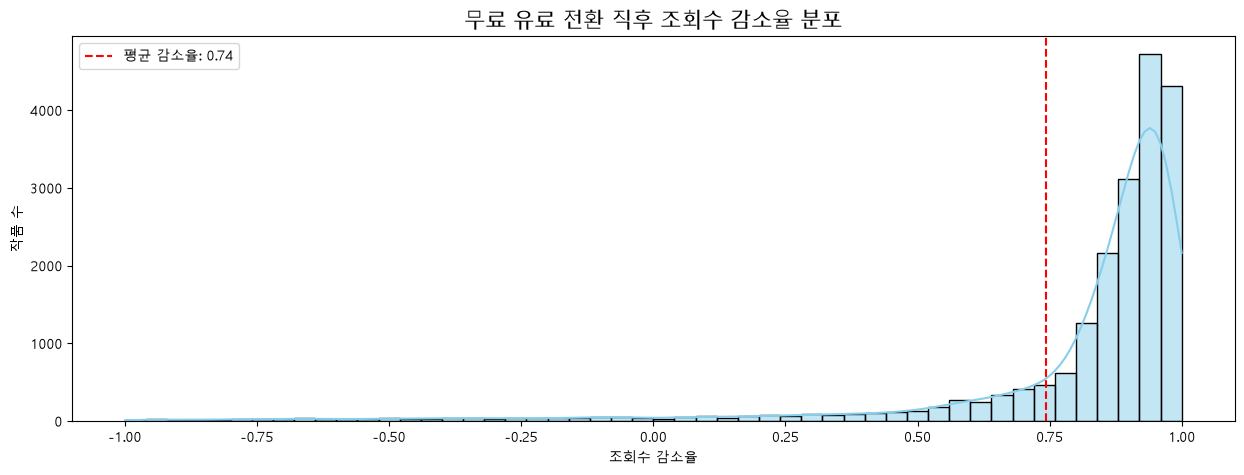

In [24]:
plt.figure(figsize=(15, 5))
plot_data = final_df[(final_df['target_drop_rate'] >= -1) & (final_df['target_drop_rate'] <= 1)]
sns.histplot(plot_data['target_drop_rate'], bins=50, kde=True, color='skyblue')
plt.title('무료 유료 전환 직후 조회수 감소율 분포', fontsize=15)
plt.xlabel('조회수 감소율')
plt.ylabel('작품 수')
plt.axvline(final_df['target_drop_rate'].mean(), color='red', linestyle='--', label=f"평균 감소율: {final_df['target_drop_rate'].mean():.2f}")
plt.legend()
plt.show()

0 = 변화 없음, 1.0 = 100% 감소, -1.0 = 100% 증가

어떤 변수가 조회수 감소율과 가장 관련이 있을지


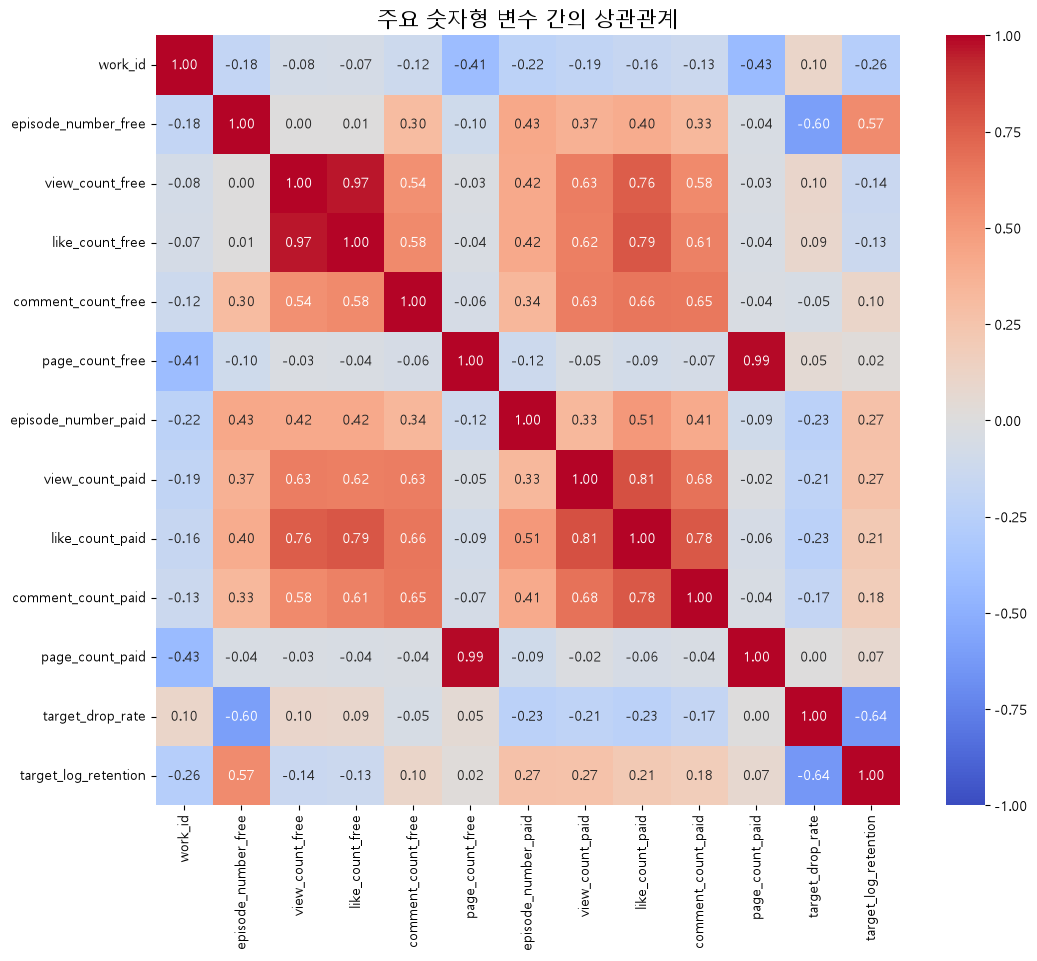

In [25]:
print("어떤 변수가 조회수 감소율과 가장 관련이 있을지")
plt.figure(figsize=(12, 10))
numeric_df = final_df.select_dtypes(include=['number']) # 숫자형 컬럼들만 골라서 상관계수 계산
corr = numeric_df.corr()

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('주요 숫자형 변수 간의 상관관계', fontsize=15)
# plt.xticks(rotation=45)
plt.show()

##### 조회수 감소율
=> 무료 연재 회차가 클수록 (오래 무료 연재를 했을수록) 유료 전환 시 조회수 감소율이 낮다 => 오래 무료 연재한 작품이 유료로 전환했을 때 조회수가 크게 떨어지지 않는다   
==> 무료회차의 조회/좋아요/댓글 수는 생각보다 조회수 감소율과 큰 영향이 없는 것으로 보임   

##### 유지비
=> 유지비 역시 무료 연재 회차와 제일 관련이 있는 것으로 보임

장르별로 이탈률이 다를지?


C:\Users\Playdata\AppData\Local\Temp\ipykernel_3412\2229563042.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='genre_best_name', y='target_drop_rate', data=plot_data, palette='Set3')


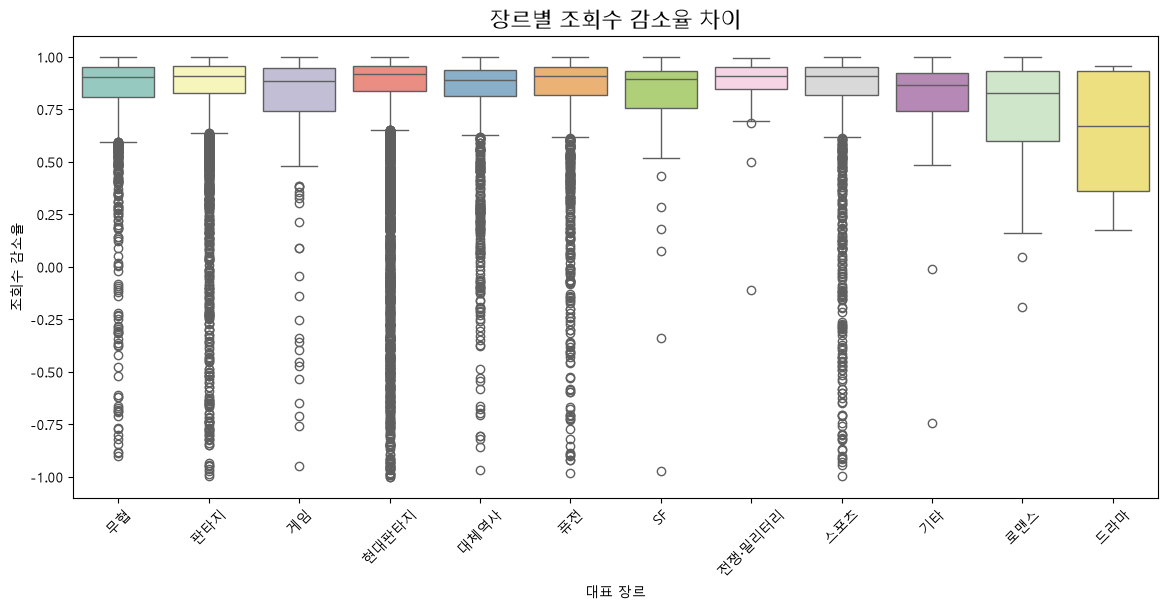

In [26]:
print("장르별로 이탈률이 다를지?")
plt.figure(figsize=(14, 6))
# 장르별 편차가 큰지, 특정 장르가 유독 방어를 잘하는지 확인
plot_data = final_df[(final_df['target_drop_rate'] >= -1) & (final_df['target_drop_rate'] <= 1)]
sns.boxplot(x='genre_best_name', y='target_drop_rate', data=plot_data, palette='Set3')
plt.title('장르별 조회수 감소율 차이', fontsize=15)
plt.xlabel('대표 장르')
plt.ylabel('조회수 감소율')
plt.xticks(rotation=45) 
plt.show()

(0 = 변화 없음, 1.0 = 100% 감소, -1.0 = 100% 증가)    
=> 특별히 압도적으로 차이가 나는 장르는 없는 것으로 보임 ..   
==> 그나마 드라마 장르가 전체적으로 조회수 감소율이 다른 장르에 비해서는 적은 감소율을 보이고 있음.

좋아요, 댓글이 많으면 이탈률 방어가 잘 될까?


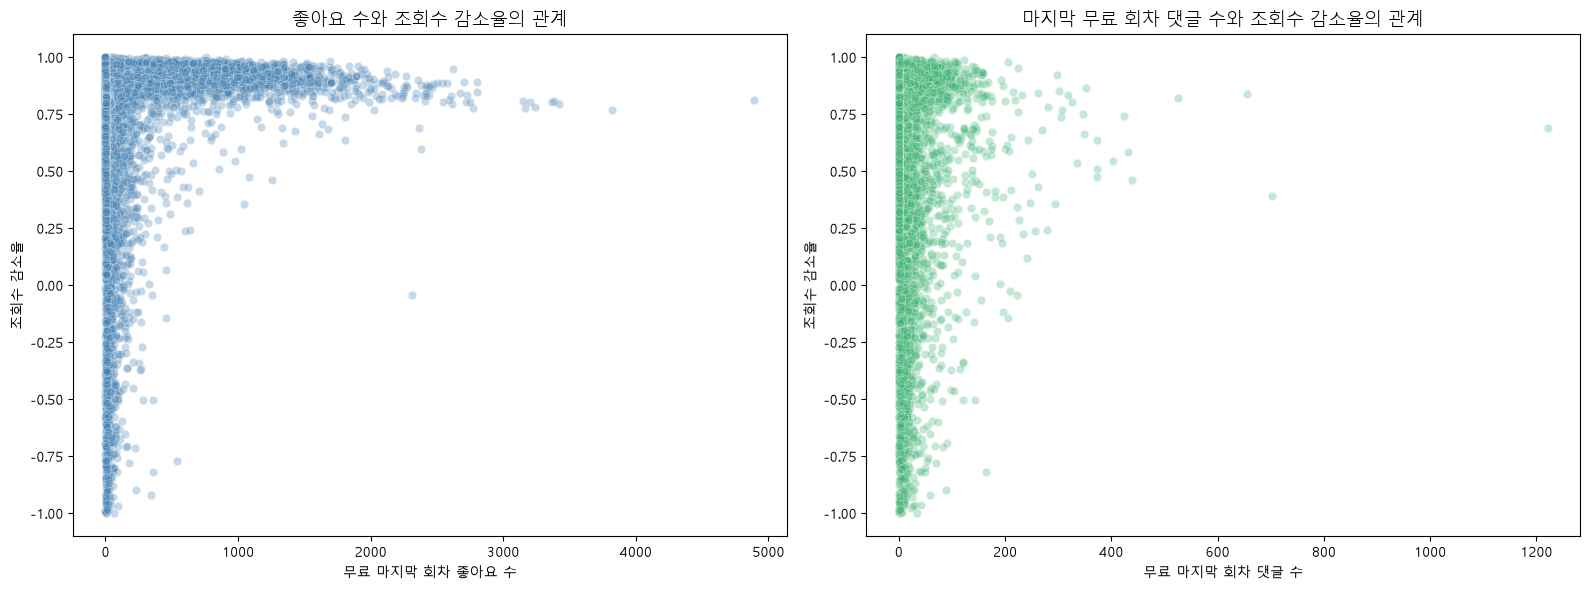

In [27]:
print("좋아요, 댓글이 많으면 이탈률 방어가 잘 될까?")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 마지막 무료 회차 좋아요 수 vs 감소율
sns.scatterplot(x='like_count_free', y='target_drop_rate', data=plot_data, ax=axes[0], 
                alpha=0.3, color='steelblue')
axes[0].set_title('좋아요 수와 조회수 감소율의 관계', fontsize=13)
axes[0].set_xlabel('무료 마지막 회차 좋아요 수')
axes[0].set_ylabel('조회수 감소율')

# 마지막 무료 회차 댓글 수 vs 감소율
sns.scatterplot(x='comment_count_free', y='target_drop_rate', data=plot_data, ax=axes[1], 
                alpha=0.3, color='mediumseagreen')
axes[1].set_title('마지막 무료 회차 댓글 수와 조회수 감소율의 관계', fontsize=13)
axes[1].set_xlabel('무료 마지막 회차 댓글 수')
axes[1].set_ylabel('조회수 감소율')

plt.tight_layout()
plt.show()

=> 댓글이나 좋아요의 수만으로는 큰 관련이 있는 것은 아닌 걸로 보인다

조회수 감소율 - 머신러닝

In [28]:
feature_cols = [
    'episode_number_free', 
    'page_count_free', 
    'view_count_free', 
    'like_count_free', 
    'comment_count_free'
]

# 2. 입력 데이터(X)와 정답 데이터(y) 분리
X = final_df[feature_cols]
y = final_df['target_drop_rate']  # 타겟 - 조회수 감소율

# 3. 학습용(Train)과 테스트용(Test)으로 분리 (8:2 비율)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42
)

# 4. 데이터 스케일링 (정규화: 평균 0, 표준편차 1)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # 학습 데이터는 fit_transform
X_test_scaled = scaler.transform(X_test)        # 테스트 데이터는 transform

print(f"학습용 작품 수: {len(X_train)}개, 테스트용 작품 수: {len(X_test)}개")

학습용 작품 수: 16226개, 테스트용 작품 수: 4057개


In [ ]:
def check_metrics(model, model_name, X_train, X_test, y_train, y_test):
    # 1. 모델 학습
    model.fit(X_train, y_train)

    # 2. 예측
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    # 3. 회귀 평가지표 계산 (Train)
    mae_train = mean_absolute_error(y_train, y_pred_train)
    mse_train = mean_squared_error(y_train, y_pred_train)
    rmse_train = np.sqrt(mse_train) # MSE에 루트를 씌운 값 (실제 오차 스케일과 비슷해짐)
    r2_train = r2_score(y_train, y_pred_train)

    # 4. 회귀 평가지표 계산 (Test)
    mae_test = mean_absolute_error(y_test, y_pred_test)
    mse_test = mean_squared_error(y_test, y_pred_test)
    rmse_test = np.sqrt(mse_test)
    r2_test = r2_score(y_test, y_pred_test)

    # 5. 결과 출력
    print(f"[{model_name}] 학습 데이터 평가")
    print(f" - MAE  : {mae_train:.4f} (실제 감소율과 평균 {mae_train*100:.1f}% 오차)")
    print(f" - RMSE : {rmse_train:.4f}")
    print(f" - R2   : {r2_train:.4f} (설명력)")
    print('-' * 50)
    print(f"[{model_name}] 테스트 데이터 평가")
    print(f" - MAE  : {mae_test:.4f} (실제 감소율과 평균 {mae_test*100:.1f}% 오차)")
    print(f" - RMSE : {rmse_test:.4f}")
    print(f" - R2   : {r2_test:.4f} (설명력)")
    print('=' * 50)

    # 나중에 모델별 성능을 비교하기 위해 결과값을 딕셔너리로 반환
    return {
        'model': model_name,
        'mae': mae_test,
        'rmse': rmse_test,
        'r2_score': r2_test
    }

In [ ]:
# 머신러닝 - 랜덤포레스트
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_result = check_metrics(rf_model, "Random Forest (감소율)", X_train_scaled, X_test_scaled, y_train, y_test)

[Random Forest (ML)] 학습 데이터 평가
 - MAE  : 0.0515 (실제 감소율과 평균 5.1% 오차)
 - RMSE : 0.1866
 - R2   : 0.9267 (설명력)
--------------------------------------------------
[Random Forest (ML)] 테스트 데이터 평가
 - MAE  : 0.1309 (실제 감소율과 평균 13.1% 오차)
 - RMSE : 0.4128
 - R2   : 0.5618 (설명력)


In [ ]:
# 머신러닝 - XGBoost
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_result = check_metrics(xgb_model, "XGBoost (감소율)", X_train_scaled, X_test_scaled, y_train, y_test)

[XGBoost (ML)] 학습 데이터 평가
 - MAE  : 0.0876 (실제 감소율과 평균 8.8% 오차)
 - RMSE : 0.2064
 - R2   : 0.9103 (설명력)
--------------------------------------------------
[XGBoost (ML)] 테스트 데이터 평가
 - MAE  : 0.1297 (실제 감소율과 평균 13.0% 오차)
 - RMSE : 0.4192
 - R2   : 0.5480 (설명력)


조회수 감소율 - 딥러닝 (다층퍼셉트론 MLP)

In [32]:
SEED = 42 
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

BATCH_SIZE = 128

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"사용 장치: {device}")

사용 장치: cpu


In [33]:
# 데이터를 텐서로 변환
X_train_tensor = torch.FloatTensor(X_train_scaled)
y_train_tensor = torch.FloatTensor(y_train.values).view(-1, 1)

X_test_tensor = torch.FloatTensor(X_test_scaled)
y_test_tensor = torch.FloatTensor(y_test.values).view(-1, 1)

C:\Users\Playdata\AppData\Local\Temp\ipykernel_3412\3635104451.py:3: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  y_train_tensor = torch.FloatTensor(y_train.values).view(-1, 1)


In [34]:
X_train_tensor.size(), y_train_tensor.size(), X_test_tensor.size(), y_test_tensor.size()

(torch.Size([16226, 5]),
 torch.Size([16226, 1]),
 torch.Size([4057, 5]),
 torch.Size([4057, 1]))

In [35]:
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)  # 검증용

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [36]:
class MLP(nn.Module):
    def __init__(self, input_dim, dropout_rate=0.3):
        super().__init__()
        
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.SiLU(),
            nn.Dropout(dropout_rate),
            
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.SiLU(),
            nn.Dropout(dropout_rate),
            
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.SiLU(),
            
            nn.Linear(32, 1) 
        )

    def forward(self, x):
        return self.network(x)

input_dim = X_train_scaled.shape[1]
model = MLP(input_dim=input_dim).to(device)

In [37]:
criterion = nn.MSELoss() 
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)

class EarlyStopping:
    def __init__(self, patience=5, min_delta=0.0001):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = float('inf')
        self.counter = 0
        self.best_state = None

    def __call__(self, valid_loss, model):
        if valid_loss < self.best_loss - self.min_delta:
            self.best_loss = valid_loss
            self.counter = 0
            self.best_state = {
                k: v.cpu().clone() 
                for k, v in model.state_dict().items()
            }
            return False
        self.counter += 1
        return self.counter >= self.patience

    def restore_best_weights(self, model):
        if self.best_state is not None:
            model.load_state_dict(self.best_state)

In [38]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    
    for inputs, targets in dataloader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        
        outputs = model(inputs)
        loss = criterion(outputs, targets) # MSE 계산
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        total_loss += loss.item() * inputs.size(0)
        
    avg_loss = total_loss / len(dataloader.dataset)
    return avg_loss

In [39]:
def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0.0
    
    with torch.no_grad():
        for inputs, targets in dataloader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            
            total_loss += loss.item() * inputs.size(0)
            
    avg_loss = total_loss / len(dataloader.dataset)
    return avg_loss

In [40]:
EPOCHS = 100
early_stopping = EarlyStopping(patience=5, min_delta=0.0001)
history = []

for epoch in range(EPOCHS):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
    valid_loss = evaluate(model, valid_loader, criterion, device)
    
    scheduler.step(valid_loss)
    current_lr = optimizer.param_groups[0]['lr']
    
    history.append({
        'epoch': epoch + 1,
        'train_loss': train_loss,
        'valid_loss': valid_loss,
        'lr': current_lr
    })
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:03d} | Train Loss: {train_loss:.4f} | Valid Loss: {valid_loss:.4f} | LR: {current_lr:.6f}")
        
    if early_stopping(valid_loss, model):
        print(f'Epoch {epoch+1}: 검증 손실 개선이 없어 EarlyStopping 작동')
        break

early_stopping.restore_best_weights(model)

Epoch 010 | Train Loss: 0.2667 | Valid Loss: 0.1580 | LR: 0.001000
Epoch 12: 검증 손실 개선이 없어 EarlyStopping 작동


In [ ]:
model.eval()
with torch.no_grad():
    y_pred_dl = model(X_test_tensor.to(device)).cpu().numpy().flatten()
    y_true_dl = y_test_tensor.numpy().flatten()

mae = mean_absolute_error(y_true_dl, y_pred_dl)
rmse = np.sqrt(mean_squared_error(y_true_dl, y_pred_dl))
r2 = r2_score(y_true_dl, y_pred_dl)

# 오차 허용 정확도 (±5%)
tolerance = 0.05
acc = np.mean(np.abs(y_true_dl - y_pred_dl) <= tolerance) * 100

print("\n[MLP (감소율)] 학습 데이터 평가")
print(f" - MAE  : {mae:.4f}")
print(f" - RMSE : {rmse:.4f}")
print(f" - R2   : {r2:.4f}")
print(f" - 정확도: {acc:.1f}% (오차 ±5%p 이내)")


[MLP (DL) 학습 데이터 평가] 
 - MAE  : 0.1377
 - RMSE : 0.3871
 - R2   : 0.6146
 - 정확도: 46.4% (오차 ±5%p 이내)


In [42]:
# 모델 비교

유지비 - 머신러닝

In [46]:
# 로그 유지비 - 머신러닝 딥러닝

y_log = final_df['target_log_retention']
X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(
    X, 
    y_log, 
    test_size=0.2, 
    random_state=42
)

scaler_log = StandardScaler()
X_train_scaled_log = scaler_log.fit_transform(X_train_log)
X_test_scaled_log = scaler_log.transform(X_test_log)

In [ ]:
# 랜덤포레스트
rf_model_log = RandomForestRegressor(n_estimators=100, random_state=42)
rf_result_log = check_metrics(rf_model_log, "Random Forest (로그 유지비)", X_train_scaled_log, X_test_scaled_log, y_train_log, y_test_log)

[Random Forest (로그 유지비)] 학습 데이터 평가
 - MAE  : 0.2451 (실제 감소율과 평균 24.5% 오차)
 - RMSE : 0.3487
 - R2   : 0.9095 (설명력)
--------------------------------------------------
[Random Forest (로그 유지비)] 테스트 데이터 평가
 - MAE  : 0.5358 (실제 감소율과 평균 53.6% 오차)
 - RMSE : 0.6951
 - R2   : 0.6381 (설명력)


In [ ]:
# XGBoost
xgb_model_log = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_result_log = check_metrics(xgb_model_log, "XGBoost (로그 유지비)", X_train_scaled_log, X_test_scaled_log, y_train_log, y_test_log)

[XGBoost (로그 유지비)] 학습 데이터 평가
 - MAE  : 0.4537 (실제 감소율과 평균 45.4% 오차)
 - RMSE : 0.5929
 - R2   : 0.7383 (설명력)
--------------------------------------------------
[XGBoost (로그 유지비)] 테스트 데이터 평가
 - MAE  : 0.5053 (실제 감소율과 평균 50.5% 오차)
 - RMSE : 0.6565
 - R2   : 0.6772 (설명력)


유지비 - 딥러닝

In [49]:
# 텐서(Tensor) 변환
X_train_tensor_log = torch.FloatTensor(X_train_scaled_log)
y_train_tensor_log = torch.FloatTensor(y_train_log.values).view(-1, 1)
X_test_tensor_log = torch.FloatTensor(X_test_scaled_log)
y_test_tensor_log = torch.FloatTensor(y_test_log.values).view(-1, 1)

In [50]:
# 데이터로더 생성
train_loader_log = DataLoader(TensorDataset(X_train_tensor_log, y_train_tensor_log), batch_size=128, shuffle=True)
valid_loader_log = DataLoader(TensorDataset(X_test_tensor_log, y_test_tensor_log), batch_size=128, shuffle=False)

# 모델, 손실함수, 옵티마이저 초기화
dl_model_log = MLP(input_dim=X_train_scaled_log.shape[1]).to(device)
criterion_log = nn.MSELoss() 
optimizer_log = optim.AdamW(dl_model_log.parameters(), lr=0.001, weight_decay=1e-4)
early_stopping_log = EarlyStopping(patience=5, min_delta=0.0001)

In [51]:
# 딥러닝 학습 루프 
EPOCHS = 100
for epoch in range(EPOCHS):
    dl_model_log.train()
    for inputs, targets in train_loader_log:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer_log.zero_grad()
        loss = criterion_log(dl_model_log(inputs), targets)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(dl_model_log.parameters(), max_norm=1.0)
        optimizer_log.step()
        
    # 평가 모드로 Valid Loss
    dl_model_log.eval()
    valid_loss_log = 0.0
    with torch.no_grad():
        for inputs, targets in valid_loader_log:
            inputs, targets = inputs.to(device), targets.to(device)
            valid_loss_log += criterion_log(dl_model_log(inputs), targets).item() * inputs.size(0)
    valid_loss_log /= len(valid_loader_log.dataset)
    
    if early_stopping_log(valid_loss_log, dl_model_log):
        print(f"Epoch {epoch + 1}: 검증 손실 개선 없어 EarlyStopping 작동")
        break

early_stopping_log.restore_best_weights(dl_model_log)

Epoch 19: 검증 손실 개선 없어 EarlyStopping 작동


In [ ]:
# 딥러닝 최종 평가 출력
dl_model_log.eval()
with torch.no_grad():
    y_pred_dl_log = dl_model_log(X_test_tensor_log.to(device)).cpu().numpy().flatten()
    y_true_dl_log = y_test_tensor_log.numpy().flatten()

mae_dl_log = mean_absolute_error(y_true_dl_log, y_pred_dl_log)
rmse_dl_log = np.sqrt(mean_squared_error(y_true_dl_log, y_pred_dl_log))
r2_dl_log = r2_score(y_true_dl_log, y_pred_dl_log)

print(f"[MLP (로그 유지비)] 테스트 데이터 평가")
print(f" - MAE  : {mae_dl_log:.4f}")
print(f" - RMSE : {rmse_dl_log:.4f}")
print(f" - R2   : {r2_dl_log:.4f}")

[MLP 딥러닝 (로그 유지비)] 테스트 데이터 평가
 - MAE  : 0.5548
 - RMSE : 0.7061
 - R2   : 0.6266


In [45]:
# 모델 비교